In [1]:
# ============================================
# SafeStreet AI
# Phase 13.2 - Data Exploration
# Notebook: 01_data_exploration.ipynb
# ============================================

import pandas as pd
import numpy as np

print("Pandas Version :", pd.__version__)
print("NumPy Version  :", np.__version__)

Pandas Version : 3.0.3
NumPy Version  : 2.4.6


In [4]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/raw/chicago_crime.csv")

df = pd.read_csv(
    DATA_PATH,
    nrows=100000
)

print(f"Rows Loaded : {len(df):,}")
print(f"Columns     : {len(df.columns)}")

Rows Loaded : 100,000
Columns     : 22


In [5]:
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,11646166,JC213529,09/01/2018 12:01:00 AM,082XX S INGLESIDE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,8.0,44.0,06,NaN,NaN,2018,04/06/2019 04:04:43 PM,NaN,NaN,NaN
1,11645836,JC212333,05/01/2016 12:25:00 AM,055XX S ROCKWELL ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,15.0,63.0,11,NaN,NaN,2016,04/06/2019 04:04:43 PM,NaN,NaN,NaN
2,11449702,JB373031,07/31/2018 01:30:00 PM,009XX E HYDE PARK BLVD,2024,NARCOTICS,POSS: HEROIN(WHITE),STREET,True,False,...,5.0,41.0,18,NaN,NaN,2018,04/09/2019 04:24:58 PM,NaN,NaN,NaN
3,11643334,JC209972,12/19/2018 04:30:00 PM,056XX W WELLINGTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,31.0,19.0,14,NaN,NaN,2018,04/04/2019 04:16:11 PM,NaN,NaN,NaN
4,11645527,JC212744,02/02/2015 10:00:00 AM,069XX W ARCHER AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,OTHER,False,False,...,23.0,56.0,11,NaN,NaN,2015,04/06/2019 04:04:43 PM,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    100000 non-null  int64  
 1   Case Number           99999 non-null   str    
 2   Date                  100000 non-null  str    
 3   Block                 100000 non-null  str    
 4   IUCR                  100000 non-null  str    
 5   Primary Type          100000 non-null  str    
 6   Description           100000 non-null  str    
 7   Location Description  98414 non-null   str    
 8   Arrest                100000 non-null  bool   
 9   Domestic              100000 non-null  bool   
 10  Beat                  100000 non-null  int64  
 11  District              100000 non-null  int64  
 12  Ward                  89532 non-null   float64
 13  Community Area        89605 non-null   float64
 14  FBI Code              100000 non-null  str    
 15  X Coordinate

In [7]:
df.columns.tolist()

['ID',
 'Case Number',
 'Date',
 'Block',
 'IUCR',
 'Primary Type',
 'Description',
 'Location Description',
 'Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'FBI Code',
 'X Coordinate',
 'Y Coordinate',
 'Year',
 'Updated On',
 'Latitude',
 'Longitude',
 'Location']

In [8]:
df.isnull().sum().sort_values(ascending=False)

Longitude               34184
X Coordinate            34184
Location                34184
Y Coordinate            34184
Latitude                34184
Ward                    10468
Community Area          10395
Location Description     1586
Case Number                 1
Primary Type                0
ID                          0
IUCR                        0
Block                       0
Date                        0
Beat                        0
District                    0
Arrest                      0
Domestic                    0
Description                 0
FBI Code                    0
Year                        0
Updated On                  0
dtype: int64

In [9]:
df.dtypes

ID                        int64
Case Number                 str
Date                        str
Block                       str
IUCR                        str
Primary Type                str
Description                 str
Location Description        str
Arrest                     bool
Domestic                   bool
Beat                      int64
District                  int64
Ward                    float64
Community Area          float64
FBI Code                    str
X Coordinate            float64
Y Coordinate            float64
Year                      int64
Updated On                  str
Latitude                float64
Longitude               float64
Location                    str
dtype: object

In [10]:
df['Date'].head(10)

0    09/01/2018 12:01:00 AM
1    05/01/2016 12:25:00 AM
2    07/31/2018 01:30:00 PM
3    12/19/2018 04:30:00 PM
4    02/02/2015 10:00:00 AM
5    01/01/2001 11:00:00 AM
6    09/03/2015 06:00:00 PM
7    12/04/2017 12:00:00 AM
8    01/01/2018 08:00:00 AM
9    12/20/2018 04:00:00 PM
Name: Date, dtype: str

In [11]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%m/%d/%Y %I:%M:%S %p'
)

print(df['Date'].dtype)

datetime64[us]


In [12]:
df['Hour'] = df['Date'].dt.hour

df[['Date', 'Hour']].head(10)

,Date,Hour
0,2018-09-01 00:01:00,0
1,2016-05-01 00:25:00,0
2,2018-07-31 13:30:00,13
3,2018-12-19 16:30:00,16
4,2015-02-02 10:00:00,10
5,2001-01-01 11:00:00,11
6,2015-09-03 18:00:00,18
7,2017-12-04 00:00:00,0
8,2018-01-01 08:00:00,8
9,2018-12-20 16:00:00,16


In [13]:
crime_by_hour = df['Hour'].value_counts().sort_index()

crime_by_hour

Hour
0     9493
1     2734
2     2236
3     1817
4     1377
5     1240
6     1516
7     2190
8     3774
9     5755
10    4319
11    4294
12    6849
13    4574
14    4858
15    5119
16    4544
17    4767
18    5080
19    4981
20    5095
21    4837
22    4601
23    3950
Name: count, dtype: int64

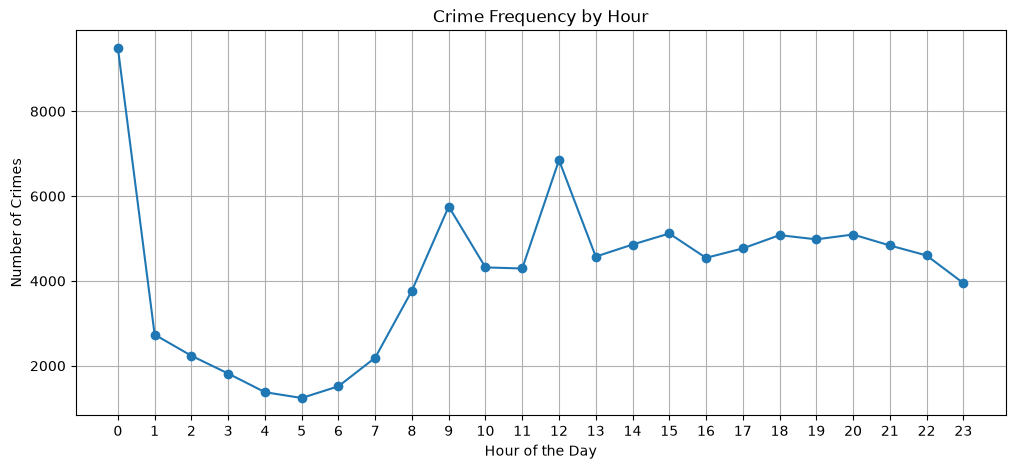

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    crime_by_hour.index,
    crime_by_hour.values,
    marker='o'
)

plt.title("Crime Frequency by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Crimes")

plt.xticks(range(24))

plt.grid(True)

plt.show()

In [15]:
df['Primary Type'].value_counts().head(15)

Primary Type
THEFT                         22696
BATTERY                       14381
NARCOTICS                     11035
DECEPTIVE PRACTICE            10012
CRIMINAL DAMAGE                9225
OTHER OFFENSE                  5856
ASSAULT                        5032
MOTOR VEHICLE THEFT            4654
BURGLARY                       4292
ROBBERY                        3288
CRIMINAL TRESPASS              2160
OFFENSE INVOLVING CHILDREN     1603
CRIM SEXUAL ASSAULT            1065
PROSTITUTION                   1045
SEX OFFENSE                    1016
Name: count, dtype: int64

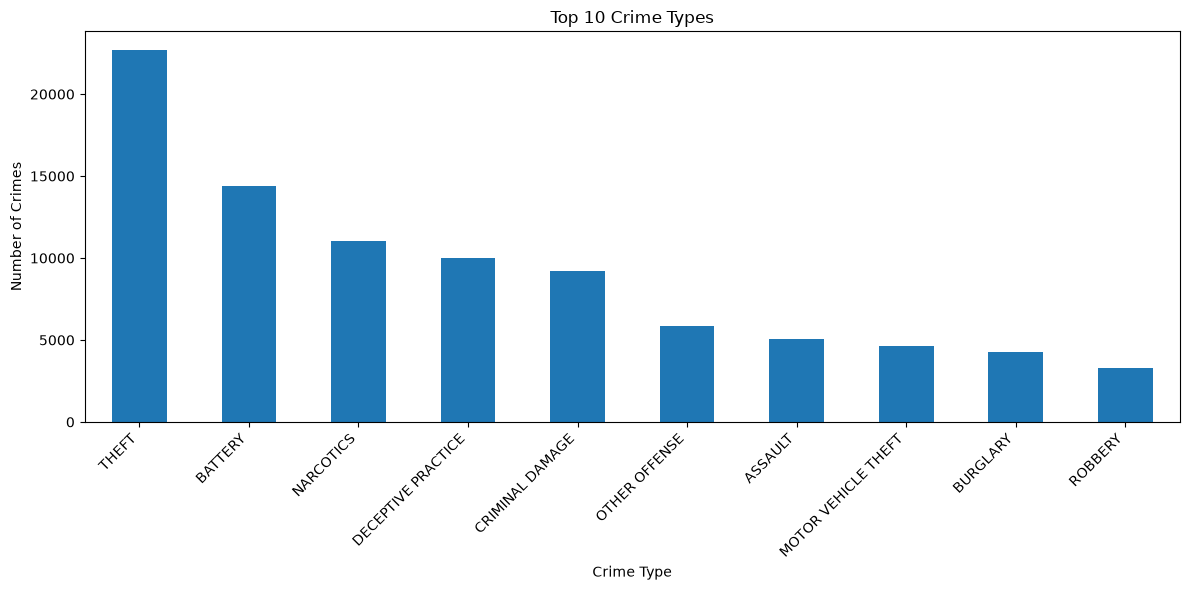

In [16]:
top_crimes = df['Primary Type'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_crimes.plot(kind='bar')

plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

In [17]:
crime_percentage = (
    df['Primary Type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

crime_percentage.head(10)

Primary Type
THEFT                  22.70
BATTERY                14.38
NARCOTICS              11.04
DECEPTIVE PRACTICE     10.01
CRIMINAL DAMAGE         9.22
OTHER OFFENSE           5.86
ASSAULT                 5.03
MOTOR VEHICLE THEFT     4.65
BURGLARY                4.29
ROBBERY                 3.29
Name: proportion, dtype: float64

In [18]:
df['Location Description'].value_counts().head(10)

Location Description
STREET                            24138
RESIDENCE                         20019
APARTMENT                         10427
SIDEWALK                           8162
OTHER                              4843
PARKING LOT/GARAGE(NON.RESID.)     2517
SMALL RETAIL STORE                 2009
ALLEY                              1864
VEHICLE NON-COMMERCIAL             1774
RESTAURANT                         1768
Name: count, dtype: int64

In [19]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [20]:
df[['Latitude', 'Longitude']].describe()

,Latitude,Longitude
count,65816.000000,65816.000000
mean,41.843249,-87.668595
std,0.087335,0.059559
min,36.619446,-91.686566
25%,41.772341,-87.708551
50%,41.853891,-87.664566
75%,41.904462,-87.627926
max,42.022644,-87.525365


In [21]:
valid_gps = df[['Latitude', 'Longitude']].dropna()

print(f"Rows with valid GPS: {len(valid_gps)}")
print(f"Rows missing GPS: {len(df) - len(valid_gps)}")
print(f"Percentage with GPS: {len(valid_gps)/len(df)*100:.2f}%")

Rows with valid GPS: 65816
Rows missing GPS: 34184
Percentage with GPS: 65.82%


In [22]:
# Remove rows without GPS coordinates
df = df.dropna(subset=['Latitude', 'Longitude']).copy()

print("Dataset shape after GPS cleaning:")
print(df.shape)

Dataset shape after GPS cleaning:
(65816, 23)


In [23]:
df['DayOfWeek'] = df['Date'].dt.dayofweek

df[['Date', 'DayOfWeek']].head(10)

,Date,DayOfWeek
6,2015-09-03 18:00:00,3
11,2015-09-05 22:42:00,5
15,2015-09-06 01:10:00,6
17,2015-09-06 02:00:00,6
23,2015-09-06 02:35:00,6
27,2015-09-06 00:01:00,6
31,2015-09-05 20:00:00,5
41,2015-09-04 20:50:00,4
70,2015-09-06 21:48:00,6
73,2015-09-07 00:11:00,0


In [24]:
df['Month'] = df['Date'].dt.month

df[['Date', 'Month']].head(10)

,Date,Month
6,2015-09-03 18:00:00,9
11,2015-09-05 22:42:00,9
15,2015-09-06 01:10:00,9
17,2015-09-06 02:00:00,9
23,2015-09-06 02:35:00,9
27,2015-09-06 00:01:00,9
31,2015-09-05 20:00:00,9
41,2015-09-04 20:50:00,9
70,2015-09-06 21:48:00,9
73,2015-09-07 00:11:00,9


In [25]:
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

df[['Date', 'DayOfWeek', 'IsWeekend']].head(10)

,Date,DayOfWeek,IsWeekend
6,2015-09-03 18:00:00,3,0
11,2015-09-05 22:42:00,5,1
15,2015-09-06 01:10:00,6,1
17,2015-09-06 02:00:00,6,1
23,2015-09-06 02:35:00,6,1
27,2015-09-06 00:01:00,6,1
31,2015-09-05 20:00:00,5,1
41,2015-09-04 20:50:00,4,0
70,2015-09-06 21:48:00,6,1
73,2015-09-07 00:11:00,0,0


In [26]:
sorted(df['Primary Type'].unique())

['ARSON',
 'ASSAULT',
 'BATTERY',
 'BURGLARY',
 'CONCEALED CARRY LICENSE VIOLATION',
 'CRIM SEXUAL ASSAULT',
 'CRIMINAL DAMAGE',
 'CRIMINAL SEXUAL ASSAULT',
 'CRIMINAL TRESPASS',
 'DECEPTIVE PRACTICE',
 'GAMBLING',
 'HOMICIDE',
 'HUMAN TRAFFICKING',
 'INTERFERENCE WITH PUBLIC OFFICER',
 'INTIMIDATION',
 'KIDNAPPING',
 'LIQUOR LAW VIOLATION',
 'MOTOR VEHICLE THEFT',
 'NARCOTICS',
 'NON-CRIMINAL',
 'OBSCENITY',
 'OFFENSE INVOLVING CHILDREN',
 'OTHER OFFENSE',
 'PROSTITUTION',
 'PUBLIC PEACE VIOLATION',
 'ROBBERY',
 'SEX OFFENSE',
 'STALKING',
 'THEFT',
 'WEAPONS VIOLATION']

In [27]:
severity_map = {
    'NON-CRIMINAL': 1,
    'OBSCENITY': 1,
    'LIQUOR LAW VIOLATION': 1,
    'GAMBLING': 1,

    'INTERFERENCE WITH PUBLIC OFFICER': 2,
    'DECEPTIVE PRACTICE': 2,
    'THEFT': 2,
    'CRIMINAL DAMAGE': 2,
    'CRIMINAL TRESPASS': 2,
    'OTHER OFFENSE': 2,
    'PUBLIC PEACE VIOLATION': 2,
    'PROSTITUTION': 2,

    'MOTOR VEHICLE THEFT': 3,
    'BURGLARY': 3,
    'NARCOTICS': 3,
    'WEAPONS VIOLATION': 3,
    'CONCEALED CARRY LICENSE VIOLATION': 3,

    'ARSON': 4,
    'BATTERY': 4,
    'ASSAULT': 4,
    'INTIMIDATION': 4,
    'STALKING': 4,

    'KIDNAPPING': 5,
    'ROBBERY': 5,
    'HOMICIDE': 5,
    'CRIM SEXUAL ASSAULT': 5,
    'CRIMINAL SEXUAL ASSAULT': 5,
    'SEX OFFENSE': 5,
    'OFFENSE INVOLVING CHILDREN': 5,
    'HUMAN TRAFFICKING': 5
}

In [28]:
df['Severity'] = df['Primary Type'].map(severity_map)

df[['Primary Type', 'Severity']].head(15)

,Primary Type,Severity
6,CRIMINAL DAMAGE,2
11,PUBLIC PEACE VIOLATION,2
15,BATTERY,4
17,BATTERY,4
23,LIQUOR LAW VIOLATION,1
27,CRIMINAL DAMAGE,2
31,BURGLARY,3
41,THEFT,2
70,CRIMINAL TRESPASS,2
73,WEAPONS VIOLATION,3


In [29]:
def severity_to_risk(severity):
    if severity <= 2:
        return "Low"
    elif severity == 3:
        return "Medium"
    else:
        return "High"

df['RiskLevel'] = df['Severity'].apply(severity_to_risk)

df[['Primary Type', 'Severity', 'RiskLevel']].head(15)

,Primary Type,Severity,RiskLevel
6,CRIMINAL DAMAGE,2,Low
11,PUBLIC PEACE VIOLATION,2,Low
15,BATTERY,4,High
17,BATTERY,4,High
23,LIQUOR LAW VIOLATION,1,Low
27,CRIMINAL DAMAGE,2,Low
31,BURGLARY,3,Medium
41,THEFT,2,Low
70,CRIMINAL TRESPASS,2,Low
73,WEAPONS VIOLATION,3,Medium


In [30]:
df['RiskLevel'].value_counts()

RiskLevel
Low       31530
High      19929
Medium    14357
Name: count, dtype: int64

In [31]:
df['RiskLevel'].value_counts(normalize=True).mul(100).round(2)

RiskLevel
Low       47.91
High      30.28
Medium    21.81
Name: proportion, dtype: float64

In [32]:
features = [
    'Latitude',
    'Longitude',
    'Hour',
    'DayOfWeek',
    'Month',
    'IsWeekend',
    'District',
    'Community Area',
    'Location Description'
]

target = 'RiskLevel'

print("Selected Features:")
print(features)

print("\nTarget:")
print(target)

Selected Features:
['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'District', 'Community Area', 'Location Description']

Target:
RiskLevel


In [33]:
X = df[features].copy()
y = df[target].copy()

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

Feature Matrix Shape : (65816, 9)
Target Shape         : (65816,)

Feature Columns:
['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'District', 'Community Area', 'Location Description']


In [34]:
X.dtypes

Latitude                float64
Longitude               float64
Hour                      int32
DayOfWeek                 int32
Month                     int32
IsWeekend                 int64
District                  int64
Community Area          float64
Location Description        str
dtype: object

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [36]:
categorical_features = ['Location Description']

numerical_features = [
    'Latitude',
    'Longitude',
    'Hour',
    'DayOfWeek',
    'Month',
    'IsWeekend',
    'District',
    'Community Area'
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Location Description']

Numerical Features:
['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'District', 'Community Area']


In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

print(preprocessor)

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Location Description'])])


In [38]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Location Description'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

print("\nTraining Labels:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting Labels:")
print(y_test.value_counts(normalize=True).round(3))

Training Set : (52652, 9)
Testing Set  : (13164, 9)

Training Labels:
RiskLevel
Low       0.479
High      0.303
Medium    0.218
Name: proportion, dtype: float64

Testing Labels:
RiskLevel
Low       0.479
High      0.303
Medium    0.218
Name: proportion, dtype: float64


In [40]:
print("Training SafeStreet AI Model...")

model.fit(X_train, y_train)

print("✅ Training Completed Successfully!")

Training SafeStreet AI Model...


ValueError: Input X contains NaN.
RandomForestClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [41]:
X.isnull().sum()

Latitude                   0
Longitude                  0
Hour                       0
DayOfWeek                  0
Month                      0
IsWeekend                  0
District                   0
Community Area          6171
Location Description      57
dtype: int64

In [42]:
from sklearn.impute import SimpleImputer

In [43]:
from sklearn.pipeline import Pipeline

# Numerical preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Complete preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("✅ Production Preprocessor Created Successfully!")

✅ Production Preprocessor Created Successfully!


In [44]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

print("✅ ML Pipeline Rebuilt Successfully!")

✅ ML Pipeline Rebuilt Successfully!


In [45]:
print("🚀 Training SafeStreet AI Model...")

model.fit(X_train, y_train)

print("✅ Training Completed Successfully!")

🚀 Training SafeStreet AI Model...
✅ Training Completed Successfully!


In [46]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5467

Classification Report
              precision    recall  f1-score   support

        High       0.49      0.44      0.46      3986
         Low       0.59      0.72      0.65      6306
      Medium       0.46      0.31      0.37      2872

    accuracy                           0.55     13164
   macro avg       0.52      0.49      0.50     13164
weighted avg       0.53      0.55      0.53     13164


Confusion Matrix
[[1742 1793  451]
 [1165 4561  580]
 [ 656 1322  894]]
